<a href="https://colab.research.google.com/github/Anku192/AIML-class/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install tensorflow scikit-learn pandas matplotlib mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print(f' TensorFlow version: {tf.__version__}')

 TensorFlow version: 2.19.0


Sprint 1: loading the dataset and data exploration

In [ ]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

print('Shape:', df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
X = df.drop('Price', axis=1).values
y = df['Price'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16512, 8), Test: (4128, 8)


Sprint 2: Building the neural network

In [ ]:
def build_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 128 (512.00 B)

Sprint 3: Training the DL Model

In [ ]:
early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_cb = keras.callbacks.TensorBoard(log_dir='./logs')


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, tensorboard_cb],
    verbose=1
)

print(' Training complete!')

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.8722 - mae: 0.6988 - val_loss: 0.6392 - val_mae: 0.5460
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5568 - mae: 0.5533 - val_loss: 0.5625 - val_mae: 0.5013
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5005 - mae: 0.5201 - val_loss: 0.5746 - val_mae: 0.4715
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4631 - mae: 0.4992 - val_loss: 0.5242 - val_mae: 0.4712
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4385 - mae: 0.4833 - val_loss: 0.6352 - val_mae: 0.4652
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4249 - mae: 0.4747 - val_loss: 0.5642 - val_mae: 0.4551
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4075 - mae: 0.4614 - val_loss: 0.5840 - val_mae: 0.5150
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3970 - mae: 0.4563 - val_loss: 0.3995 - val_mae: 0.4324
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

Sprint 4: Model Evaluation

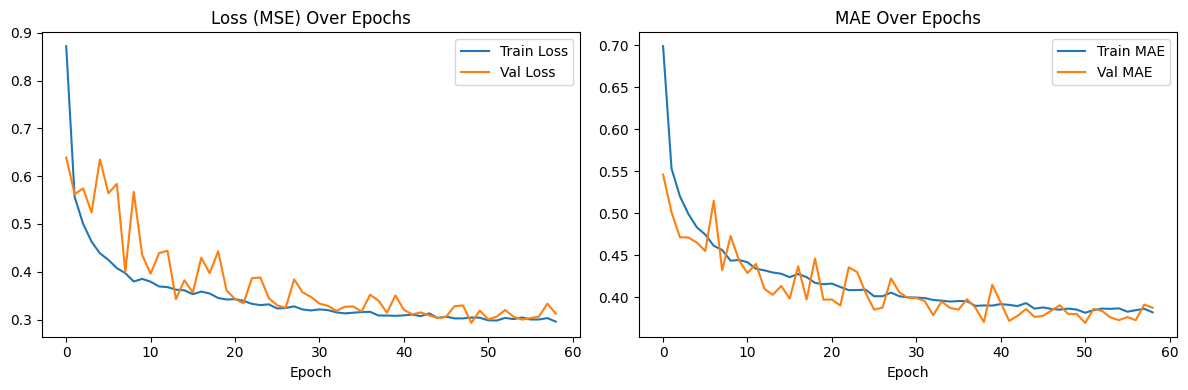

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score : {r2:.4f}')
print(f'RMSE     : {rmse:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R² Score : 0.7803
RMSE     : 0.5366


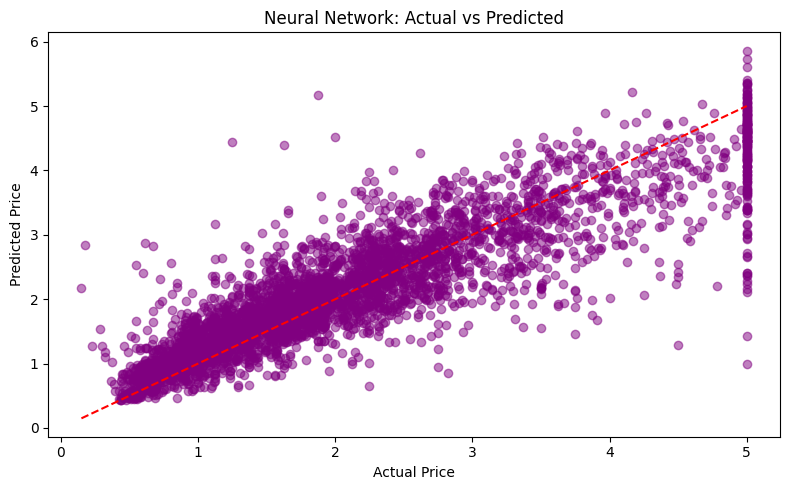

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Neural Network: Actual vs Predicted')
plt.tight_layout()
plt.show()

Sprint 5: Devops: Mlflow and tensorboard

---



In [ ]:
!pip install mlflow

import mlflow

mlflow.set_experiment('DL_Regression_Experiment')

with mlflow.start_run(run_name='NeuralNet_Run'):
    mlflow.log_param('model_type', 'Neural Network')
    mlflow.log_param('layers', '64-32-1')
    mlflow.log_param('activation', 'relu')
    mlflow.log_param('optimizer', 'adam')
    mlflow.log_metric('r2_score', r2)
    mlflow.log_metric('rmse', rmse)
    print(' MLflow run logged!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 585.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

2026/04/18 10:48:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 10:48:06 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 10:48:10 INFO mlflow.tracking.fluent: Experiment with name 'DL_Regression_Experiment' does not exist. Creating a new experiment.


 MLflow run logged!


In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score # Added for calculating R-squared

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import mlflow # Imported here to be consistent with main block


def build_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model


def train_model():
    # Load data
    data = fetch_california_housing()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['Price'] = data.target

    X = df.drop('Price', axis=1).values
    y = df['Price'].values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    # Build & train model
    model = build_model(X_train.shape[1])

    early_stop = keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    return model, scaler


def predict(model, scaler, input_data):
    input_scaled = scaler.transform([input_data])
    prediction = model.predict(input_scaled, verbose=0)
    return float(prediction[0][0])


if __name__ == "__main__":
    model, scaler = train_model()

    sample = [8.3, 41, 6.9, 1.0, 322, 2.5, 37.88, -122.23]
    result = predict(model, scaler, sample)

    print("DL Prediction:", result)

    # Re-load and split data to get X_test and y_test for model evaluation
    data_eval = fetch_california_housing()
    df_eval = pd.DataFrame(data_eval.data, columns=data_eval.feature_names)
    df_eval['Price'] = data_eval.target

    X_eval = df_eval.drop('Price', axis=1).values
    y_eval = df_eval['Price'].values

    # Get the unscaled test set
    _, X_test_unscaled, _, y_test = train_test_split(
        X_eval, y_eval, test_size=0.2, random_state=42
    )

    # Scale the test set using the fitted scaler
    X_test_scaled = scaler.transform(X_test_unscaled)

    # Make predictions on the scaled test set
    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    # Calculate R-squared score
    r2 = r2_score(y_test, y_pred)

    # Removed !pip install MLflow as it's better placed at the top of the notebook or run once.
    # import mlflow # Already imported above for consistency

    with mlflow.start_run():
        # Removed mlflow.log_param("n_estimators", 100) as it's not applicable for this model.
        mlflow.log_metric("r2_score", r2)  # Log the calculated R2 score
        mlflow.keras.log_model(model, "model") # Changed to mlflow.keras.log_model for Keras models


DL Prediction: 4.109177589416504


2026/04/21 20:29:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 20:29:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
